In [1]:
# !pip install ta
# !pip install yfinance
# !pip install statsmodels

In [66]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_score, f1_score, r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.tsa.arima.model import ARIMA

# 1. Data Collection

In [3]:
# initializing stock variable
ticker = "GOOG"

# getting and displaying the data of 11 years of GOOG's stock history
data = yf.download(ticker, start="2014-01-01", end="2026-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.498323,27.612703,27.378263,27.556132,73129082
2014-01-03,27.297731,27.592448,27.296002,27.544771,66917888
2014-01-06,27.602081,27.640124,27.333303,27.495608,71037271
2014-01-07,28.134201,28.154706,27.696945,27.791807,102486711
2014-01-08,28.192749,28.343196,27.996600,28.310587,90036218


In [4]:
data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

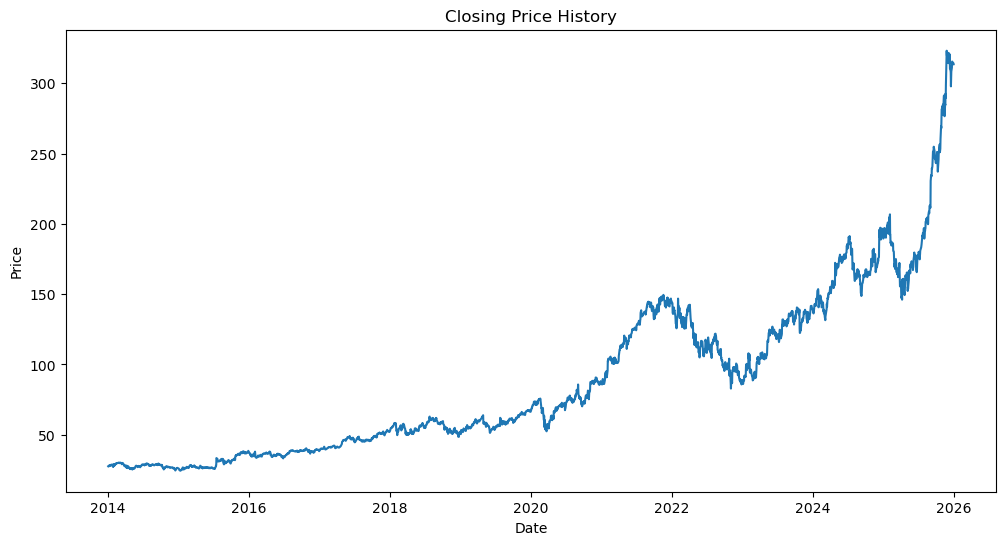

In [5]:
# display the closing price history
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Closing Price History")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# 2. Feature Engineering

In [6]:
# change in close price each day
data["Price_Change"] = data["Close"].diff()

# 20 day moving avg
data["SMA20"] = data["Close"].rolling(window=20).mean()

# 50 day moving avg
data["SMA50"] = data["Close"].rolling(window=50).mean()

# pct change between rows, today and yesterday
data["Daily_Return"] = data["Close"].pct_change()

# standard deviation of last 20 days, higher value = greater volatility
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

# yesterday's price to help predict tomorrow's price
data["Lag1_Close"] = data["Close"].shift(1)

# RSI > 70: overbought
# RSI < 30: oversold
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)

data["RSI_14"] = rsi.rsi()

# 3. Prediction Targets

In [7]:
# Define target: shift Close price to align today's data with tomorrow's outcome
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Tomorrow > Today: 1 (price went UP)
# Tomorrow <= Today: 0 (price went DOWN)
data["Direction"] = (data["Tomorrow_Close"] > data["Close"].squeeze()).astype(int)

In [8]:
# removing null values, rows contain null values because:
# SMA20 needs 20 days
# SMA50 needs 50 days
# RSI needs 14 days
data = data.dropna()

In [9]:
data.head(10)

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,,
2014-03-14,28.972647,29.419045,28.965976,29.199674,92099924,-0.401686,29.845237,28.917411,-0.013675,0.007145,29.374332,41.274355,29.449432,1
2014-03-17,29.449432,29.572211,29.103826,29.131989,86808163,0.476786,29.832021,28.956433,0.016456,0.008132,28.972647,49.471728,29.922758,1
2014-03-18,29.922758,29.929429,29.473149,29.512922,72872123,0.473326,29.832490,29.008933,0.016072,0.008805,29.449432,56.033096,29.626066,0
2014-03-19,29.626066,29.940793,29.506498,29.936099,64757822,-0.296692,29.828673,29.049413,-0.009915,0.008948,29.922758,51.517214,29.574432,0
2014-03-20,29.574432,29.881994,29.529965,29.643355,67640587,-0.051634,29.820089,29.078218,-0.001743,0.008948,29.626066,50.750643,29.225615,0
2014-03-21,29.225615,29.882491,29.211040,29.800473,128821050,-0.348818,29.794458,29.098875,-0.011795,0.009313,29.574432,45.793274,28.605301,0
2014-03-24,28.605301,29.271563,28.309347,29.254024,121939352,-0.620314,29.727042,29.112556,-0.021225,0.010152,29.225615,38.576686,28.624819,1
2014-03-25,28.624819,28.899526,28.335291,28.804664,96769361,0.019518,29.651349,29.126657,0.000682,0.009985,28.605301,38.902941,27.963989,0


In [10]:
data.describe()

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
count,2968.000000,2968.000000,2968.000000,2968.000000,2.968000e+03,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000
mean,89.223932,90.152994,88.253985,89.172637,3.080534e+07,0.096009,88.321189,86.936051,0.000958,0.016470,89.127923,54.410088,89.319824,0.536388
std,58.519058,59.193920,57.818726,58.490692,1.602053e+07,1.987102,57.127581,54.994547,0.017871,0.007184,58.383213,11.636011,58.653324,0.498758
min,24.360075,24.529516,24.113284,24.463936,1.584340e+05,-14.343994,25.322610,25.747297,-0.111008,0.002915,24.360075,24.077303,24.360075,0.000000
25%,40.854212,41.024948,40.684978,40.806979,2.099485e+07,-0.469399,40.403831,39.928708,-0.007289,0.011174,40.840078,45.916399,40.868844,0.000000
50%,66.032871,66.581860,65.304100,65.924014,2.678372e+07,0.061328,65.012167,63.812096,0.001093,0.015128,65.832764,54.725666,66.231491,1.000000
75%,131.058014,132.451447,129.586351,131.023059,3.549650e+07,0.694279,132.028307,130.786930,0.009931,0.020493,131.016735,62.782564,131.128071,1.000000
max,323.201294,328.224474,319.546256,326.356983,2.232980e+08,19.067062,314.233405,295.855741,0.160524,0.055626,323.201294,89.071334,323.201294,1.000000


In [11]:
data.columns

MultiIndex([(         'Close', 'GOOG'),
            (          'High', 'GOOG'),
            (           'Low', 'GOOG'),
            (          'Open', 'GOOG'),
            (        'Volume', 'GOOG'),
            (  'Price_Change',     ''),
            (         'SMA20',     ''),
            (         'SMA50',     ''),
            (  'Daily_Return',     ''),
            ( 'Volatility_20',     ''),
            (    'Lag1_Close',     ''),
            (        'RSI_14',     ''),
            ('Tomorrow_Close',     ''),
            (     'Direction',     '')],
           names=['Price', 'Ticker'])

# 4. Feature Engineering

In [12]:
data.loc[:, "Return_Lag1"] = data["Daily_Return"].shift(1)
data.loc[:, "Return_Lag2"] = data["Daily_Return"].shift(2)
data.loc[:, "Return_Lag3"] = data["Daily_Return"].shift(3)
data.loc[:, "SMA_diff"] = data["SMA20"] - data["SMA50"]

C:\Users\denim\AppData\Local\Temp\ipykernel_13376\1021510913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Return_Lag1"] = data["Daily_Return"].shift(1)
C:\Users\denim\AppData\Local\Temp\ipykernel_13376\1021510913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Return_Lag2"] = data["Daily_Return"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_13376\1021510913.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [13]:
data.loc[:, "Lag2_Close"] = data["Close"].shift(2)
data.loc[:, "Lag3_Close"] = data["Close"].shift(3)
data.loc[:, "Lag5_Close"] = data["Close"].shift(5)
data = data.dropna()

C:\Users\denim\AppData\Local\Temp\ipykernel_13376\3950296242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Lag2_Close"] = data["Close"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_13376\3950296242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Lag3_Close"] = data["Close"].shift(3)
C:\Users\denim\AppData\Local\Temp\ipykernel_13376\3950296242.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [14]:
# predictor variables used by the models
features = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Price_Change",
    "SMA20",
    "SMA50",
    "SMA_diff",
    "Daily_Return",
    "Volatility_20",
    "Lag1_Close",
    "Lag2_Close",
    "Lag3_Close",
    "Lag5_Close",
    "RSI_14",
    "Return_Lag1",
    "Return_Lag2",
    "Return_Lag3"
]

# feature matrix
X = data[features].copy()

# Target variable for price prediction(regression)
y_price = data["Tomorrow_Close"]

# Target variable for price direction prediction(classification)
y_direction = data["Direction"]

In [15]:
X.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in X.columns] 

In [16]:
X.columns

Index(['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG',
       'Price_Change_', 'SMA20_', 'SMA50_', 'SMA_diff_', 'Daily_Return_',
       'Volatility_20_', 'Lag1_Close_', 'Lag2_Close_', 'Lag3_Close_',
       'Lag5_Close_', 'RSI_14_', 'Return_Lag1_', 'Return_Lag2_',
       'Return_Lag3_'],
      dtype='object')

# 5. Splitting data for training and testing

In [17]:
# Splitting data for price
# shuffle off(time series data) so it doesn't train on new data and test on old, 
# Training size: 80%, Testing size: 20%
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size = 0.2,
    shuffle = False
)
X_train_price.shape, X_test_price.shape, y_train_price.shape, y_test_price.shape

((2370, 19), (593, 19), (2370,), (593,))

In [18]:
# Splitting data for direction following the same rules as above
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X,
    y_direction,
    test_size = 0.2,
    shuffle = False
)
X_train_dir.shape, X_test_dir.shape, y_train_dir.shape, y_test_dir.shape

((2370, 19), (593, 19), (2370,), (593,))

# 6. Linear Regression

In [19]:
lr_model = LinearRegression()

lr_model.fit(X_train_price, y_train_price)

LinearRegression()

In [20]:
lr_predictions = lr_model.predict(X_test_price)

In [51]:
mae = mean_absolute_error(y_test_price, lr_predictions)

rmse = np.sqrt(mean_squared_error(y_test_price, lr_predictions))

lr_r2 = r2_score(y_test_price, lr_predictions)

print(f"Linear Regression r2 score: {lr_r2:.4f}")
print(f"Linear Regression MAE: {mae:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")

Linear Regression r2 score: 0.9941
Linear Regression MAE: 2.42
Linear Regression RMSE: 3.47


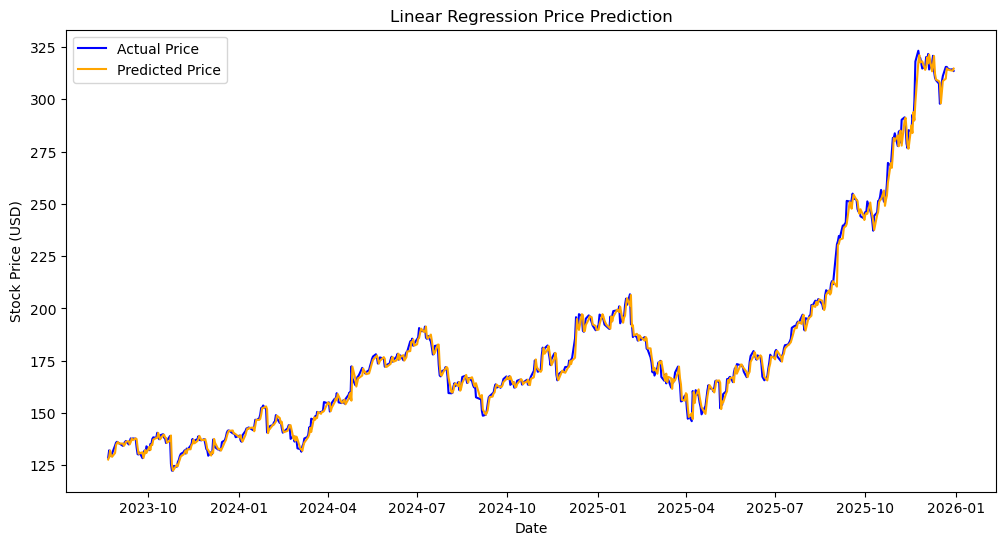

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price", color="blue")
plt.plot(y_test_price.index, lr_predictions, label="Predicted Price",color="orange")

plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.title("Linear Regression Price Prediction")
plt.legend()
plt.show()

# 7. Evaluating direction accuracy

In [23]:
# Predicted price > today's price: stock goes UP
# Predicted price =< today's price: stock goes DOWN

# Force both to be flat 1D arrays before comparing
pred_vals = lr_predictions.ravel()
actual_closes = X_test_price["Close_GOOG"].values.ravel()

# This will now be shape (594,)
predicted_direction = (pred_vals > actual_closes).astype(int)


direction_accuracy = accuracy_score(y_test_dir, predicted_direction)
print(f"Directional accuracy: {direction_accuracy:.2%}")

Directional accuracy: 54.13%


In [24]:
print("Linear Regression confusion matrix:")
print(confusion_matrix(y_test_dir, predicted_direction))

Linear Regression confusion matrix:
[[154 103]
 [169 167]]


## Linear Regression Model Evaluation
The Linear Regression model achieved an exceptional R² score of 0.9941, indicating that it tracks the actual stock price with high precision. With a Mean Absolute Error (MAE) of 2.42 and a Root Mean Squared Error (RMSE) of 3.47, the model's price predictions typically deviate by less than $3.50 from the actual closing price. This suggests the model is highly effective at capturing the overall price levels and the general trend of the data.

In terms of market direction, the model achieved a Directional Accuracy of 54.13%. The confusion matrix reveals a relatively balanced performance, though it shows a slight conservative bias. The model recorded 169 False Negatives (predicting "Down" when the price went "Up") compared to 103 False Positives (predicting "Up" when the price went "Down"). This indicates that while the model is reliable for price estimation, it is slightly more likely to miss an upward move than it is to give a false "buy" signal. Overall, the model correctly identified 167 "Up" days and 154 "Down" days, providing a solid baseline for directional forecasting.

# 8. Random Forest Regressor

In [25]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)

X_train_rf = X_train_price.drop(columns=["Close_GOOG"])
X_test_rf = X_test_price.drop(columns=["Close_GOOG"])

rf_model.fit(X_train_rf, y_train_price)

rf_predictions = rf_model.predict(X_test_rf)

rf_mae = mean_absolute_error(y_test_price, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test_price, rf_predictions))

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest MAE: 35.96
Random Forest RMSE: 55.86


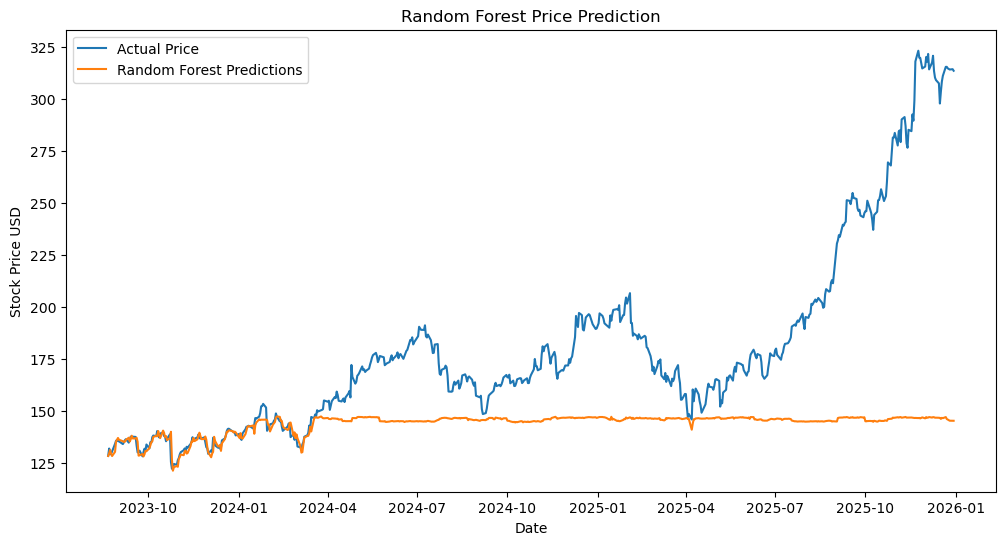

In [26]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price")
plt.plot(y_test_price.index, rf_predictions, label="Random Forest Predictions")

plt.xlabel("Date")
plt.ylabel("Stock Price USD")
plt.title("Random Forest Price Prediction")

plt.legend()

plt.show()

In [27]:
rf_pred_values = rf_predictions.ravel()

rf_direction = (rf_pred_values > actual_closes).astype(int)

rf_direction_accuracy = accuracy_score(y_test_dir, rf_direction)

print(f"Random Forest Regressor Directional Accuracy: {rf_direction_accuracy:.2%}")

Random Forest Regressor Directional Accuracy: 45.53%


In [28]:
rf_cm = confusion_matrix(y_test_dir, rf_direction)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[227  30]
 [293  43]]


## Random Forest Regressor Model Evaluation
The Random Forest model struggled significantly with price prediction, yielding a high MAE of 35.96 and an RMSE of 55.86. This performance gap is primarily due to the inherent inability of tree-based methods to extrapolate data beyond the training range. Because the stock price reached new historical highs during the test period, the model was forced to "flatline" its predictions at the highest values it had seen during training, rather than following the actual upward trajectory of the market.

In terms of market direction, the model achieved a Directional Accuracy of 45.53%. The confusion matrix highlights a severe bias toward False Negatives (293), where the model predicted a downward move for days that actually went up. While the model was relatively successful at identifying 227 "Down" days, it only correctly caught 43 "Up" days. This confirms that the model is failing to capture the upward momentum of the stock, largely because the current price levels exist outside its known training boundaries.

# 9. Random Forest Classifier

In [29]:
rf_classifier = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42)

rf_classifier.fit(X_train_dir, y_train_dir)

rf_dir_predictions = rf_classifier.predict(X_test_dir)

rf_dir_accuracy = accuracy_score(y_test_dir, rf_dir_predictions)

print(f"Random forest classifier directional accuracy {rf_dir_accuracy:.2%}")

Random forest classifier directional accuracy 45.19%


In [30]:
rf_dir_cm = confusion_matrix(y_test_dir, rf_dir_predictions)
print("Random forest classifier confusion matrix")
print(rf_dir_cm)

Random forest classifier confusion matrix
[[210  47]
 [278  58]]


In [67]:
rf_probs = rf_classifier.predict_proba(X_test_dir)[:, 1]

precision = precision_score(y_test_dir, rf_dir_predictions)
f1 = f1_score(y_test_dir, rf_dir_predictions)
roc_auc = roc_auc_score(y_test_dir, rf_probs)

print(f"Random Forest Precision: {precision:.2%}")
print(f"Random Forest F1-Score: {f1:.2%}")
print(f"Random Forest ROC-AUC: {roc_auc:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_dir, rf_dir_predictions))

Random Forest Precision: 55.24%
Random Forest F1-Score: 26.30%
Random Forest ROC-AUC: 0.4697

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.82      0.56       257
           1       0.55      0.17      0.26       336

    accuracy                           0.45       593
   macro avg       0.49      0.49      0.41       593
weighted avg       0.50      0.45      0.39       593



In [31]:
feature_importances = rf_classifier.feature_importances_

feature_names = X_train_dir.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

           Feature  Importance
4      Volume_GOOG    0.072056
18    Return_Lag3_    0.069341
15         RSI_14_    0.067464
17    Return_Lag2_    0.066918
16    Return_Lag1_    0.065214
10  Volatility_20_    0.061759
5    Price_Change_    0.057428
9    Daily_Return_    0.056733
8        SMA_diff_    0.053965
14     Lag5_Close_    0.051252
7           SMA50_    0.047052
6           SMA20_    0.043886
12     Lag2_Close_    0.042897
11     Lag1_Close_    0.041949
2         Low_GOOG    0.041462
0       Close_GOOG    0.040877
13     Lag3_Close_    0.040570
3        Open_GOOG    0.040508
1        High_GOOG    0.038669


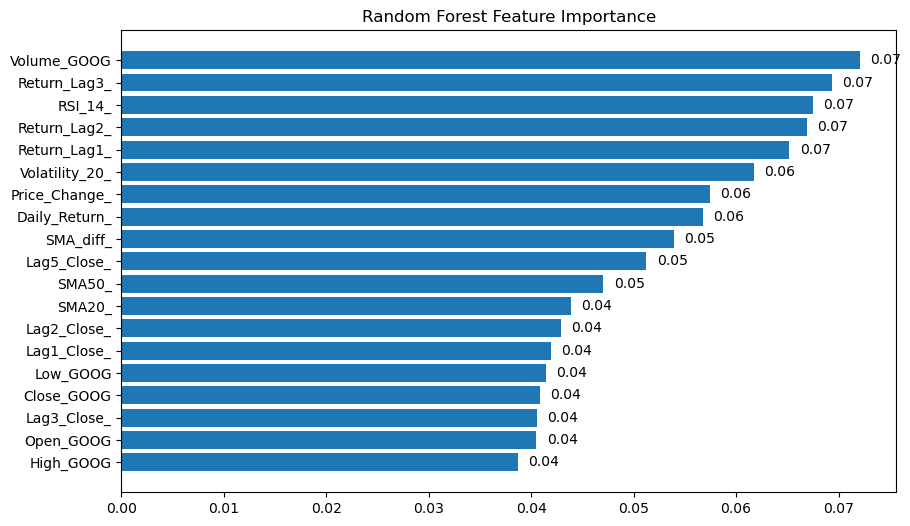

In [32]:
plt.figure(figsize=(10,6))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.title("Random Forest Feature Importance")

for i, v in enumerate(importance_df["Importance"]):
    plt.text(v + 0.001, i, f'{v:.2f}', va='center')

plt.gca().invert_yaxis()

plt.show()

The feature importance scores are relatively balanced, with only a small margin of 0.03 separating the highest-ranked feature (0.07) from the lowest (0.04). This indicates that the model utilizes a broad mix of price, volume, and technical indicators rather than being dominated by one specific predictor.

The most influential features were lagged returns and momentum indicators such as RSI, suggesting that short-term price momentum contains limited predictive information.

## Random Forest Classifier Model Evaluation
The Random Forest Classifier achieved a Directional Accuracy of 45.19%, which indicates that the model is currently underperforming compared to a random baseline (50%). While the Precision for "Up" days (Class 1) is 55.24%, suggesting that more than half of its "buy" signals were correct, the extremely low Recall of 17% shows that the model is missing the vast majority of upward moves. This is further reflected in the F1-Score of 26.30%, highlighting a significant imbalance between the model's precision and its ability to actually capture positive market trends.

The confusion matrix reveals a strong bias toward predicting downward movement (Class 0). The model correctly identified 210 "Down" days, but it recorded 278 False Negatives, failing to recognize the majority of days where the stock price actually increased. This high number of False Negatives suggests the model is overly conservative or struggling to find patterns in the features that lead to gains.

Furthermore, the ROC-AUC score of 0.4697—which is slightly below the 0.50 threshold for random guessing—confirms that the model currently lacks the ability to effectively distinguish between "Up" and "Down" days. This suggests that the current feature set may not be capturing the underlying drivers of the stock's direction.

# 10. ARIMA

In [43]:
ts_data = X["Close_GOOG"]

ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.asfreq('B').ffill()
train_size = int(len(ts_data) * 0.8)

train_ts = ts_data[:train_size]
test_ts = ts_data[train_size:]

arima_model = ARIMA(train_ts, order=(2,1,0))
arima_fit = arima_model.fit()

arima_predictions = arima_fit.forecast(steps=len(test_ts))

arima_mae = mean_absolute_error(test_ts, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_predictions))
arima_r2 = r2_score(test_ts, arima_predictions)

print(f"ARIMA MAE: {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA r2 score: {arima_r2:.2f}")

ARIMA MAE: 50.96
ARIMA RMSE: 67.91
ARIMA r2 score: -1.28


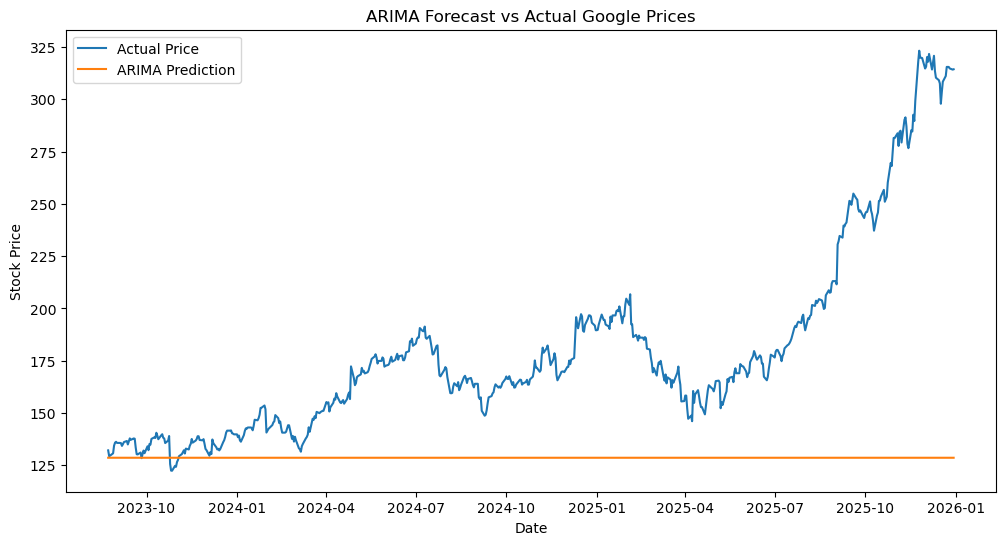

In [34]:
plt.figure(figsize=(12,6))

plt.plot(test_ts.index, test_ts, label="Actual Price")
plt.plot(test_ts.index, arima_predictions, label="ARIMA Prediction")

plt.title("ARIMA Forecast vs Actual Google Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

The static ARIMA model performed poorly, as evidenced by its MAE of 50.96 and RMSE of 67.91. These high error values indicate that the model's predictions deviated from the actual Google stock price by an average of over $50. Most significantly, the model yielded an R² score of -1.28. A negative R² score means the model is mathematically worse at predicting the price than a simple horizontal line representing the average price of the dataset.

The static ARIMA model performed poorly (R² = -1.28) because it was trained only on historical data and asked to predict a long-term future without updates. As the market moved and new trends emerged, the model remained stuck in its original training logic, causing its predictions to disconnect completely from reality. This result highlights why static models are generally unsuitable for volatile financial markets.

To fix this drift, I implemented a Rolling ARIMA (or Walk-Forward Validation) approach. Instead of predicting the entire test set at once, this method predicts only one step ahead, then updates the model with the actual observed price before making the next prediction. This allows the model to constantly recalibrate itself to the most recent market trends, mimicking how a real-world trading algorithm would operate.

# 11. Rolling ARIMA

In [41]:
history = list(train_ts)
rolling_predictions = []

# Loop through every time step in the test set
for t in range(len(test_ts)):
    model = ARIMA(history, order=(2,1,0))
    model_fit = model.fit()
    
    # Predict only the next single step
    output = model_fit.forecast()
    yhat = output[0]
    rolling_predictions.append(yhat)
    
    # Add the actual observation to history for the next loop
    obs = test_ts.iloc[t]
    history.append(obs)

In [52]:
rolling_mae = mean_absolute_error(test_ts, rolling_predictions)
rolling_rmse = np.sqrt(mean_squared_error(test_ts, rolling_predictions))
rolling_r2 = r2_score(test_ts, rolling_predictions)

print(f"Rolling ARIMA MAE: {rolling_mae:.2f}")
print(f"Rolling ARIMA RMSE: {rolling_rmse:.2f}")
print(f"Rolling ARIMA r2 score: {rolling_r2:.4f}")

Rolling ARIMA MAE: 2.33
Rolling ARIMA RMSE: 3.37
Rolling ARIMA r2 score: 0.9944


In [65]:
rolling_pred_vals = np.array(rolling_predictions).flatten()
actual_closes = test_ts.values.flatten()

# Calculate the direction for the rolling model
rolling_predicted_direction = (rolling_pred_vals > actual_closes).astype(int)

# Slice the predictions to match the 593 samples in y_test_dir
# We take the first 593 to ensure the lengths are consistent
direction_accuracy = accuracy_score(y_test_dir, rolling_predicted_direction[:len(y_test_dir)])

print(f"Directional accuracy: {direction_accuracy:.2%}")

Directional accuracy: 46.21%


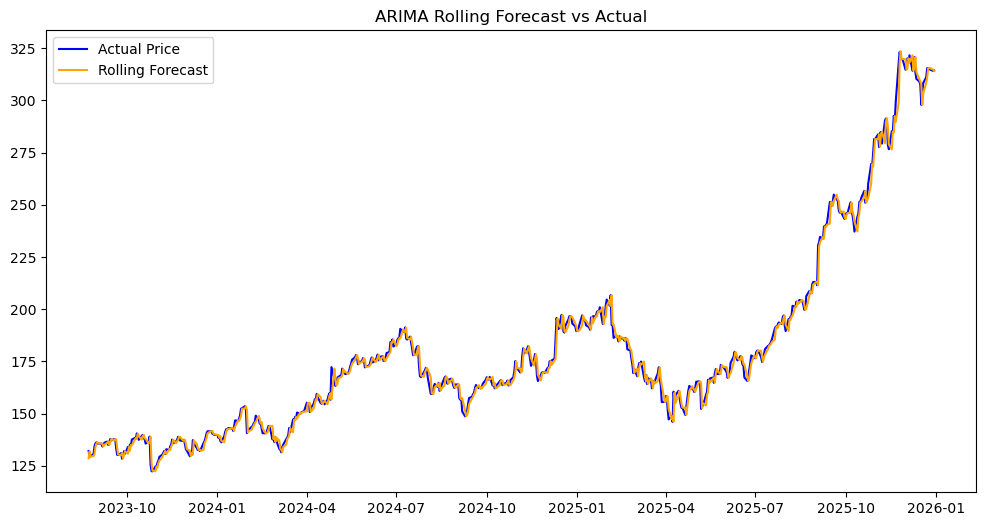

In [36]:
plt.figure(figsize=(12,6))
plt.plot(test_ts.index, test_ts, label='Actual Price', color='blue')
plt.plot(test_ts.index, rolling_predictions, label='Rolling Forecast', color="orange")
plt.title('ARIMA Rolling Forecast vs Actual')
plt.legend()
plt.show()

## Rolling ARIMA Model Evaluation
The Rolling ARIMA model represents a significant improvement over the static version, achieving an exceptional R² score of 0.9944. With a Mean Absolute Error (MAE) of 2.33 and a Root Mean Squared Error (RMSE) of 3.37, this model tracks the actual stock price with a high degree of precision, typically staying within $3.40 of the real closing price. By using a "walk-forward" approach where the model is updated with the actual price after every prediction it successfully eliminated the "model drift" that caused the static ARIMA to fail.

In terms of market direction, the model achieved a Directional Accuracy of 46.21%. Despite the near-perfect R² score, the directional accuracy remains below the 50% random-chance threshold. This indicates a "lag effect" common in time-series forecasting: while the model is excellent at predicting that tomorrow's price will be very close to today's, it often fails to anticipate the sign of the move (Up vs. Down) before it happens.

This contrast between high price precision and lower directional accuracy proves that the Rolling ARIMA is a powerful tool for price estimation, but it may require additional features to become a reliable tool for directional market timing.

In [81]:
y_direction.value_counts(normalize=True)

Direction
1    0.536618
0    0.463382
Name: proportion, dtype: float64